In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures


In [12]:
df = pd.read_csv('Ice_cream selling data.csv')
df.columns

Index(['Temperature (°C)', 'Ice Cream Sales (units)'], dtype='object')

<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

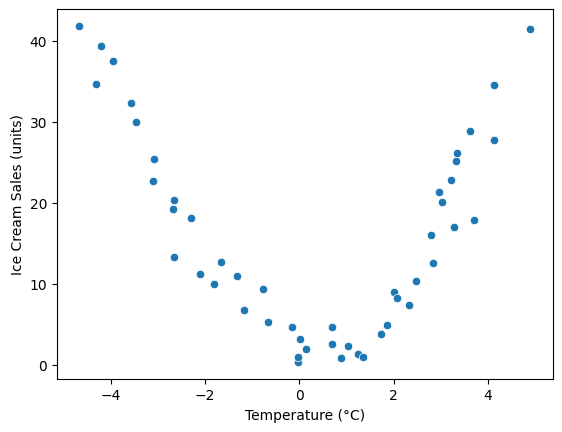

In [13]:
sns.scatterplot(data=df,x='Temperature (°C)',y='Ice Cream Sales (units)')

In [14]:
x = df[['Temperature (°C)']]
y = df[['Ice Cream Sales (units)']]

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
poly = PolynomialFeatures(degree=2)

In [19]:
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [21]:
x_test_poly

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [22]:
model= LinearRegression()
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
print(r2_score(y_pred,y_test))

0.8666323293264795


In [23]:
model.coef_

array([[ 0.        , -0.70641926,  1.87145125]])

In [24]:
model.intercept_

array([2.76830583])

In [25]:
df = pd.read_csv('Fish.csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [26]:
model.predict(poly.transform(np.array([[15]])))

C:\Users\mistr\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[413.24854806]])

In [27]:
y=df[['Weight']]
x=df[['Length1','Length2','Length3','Height','Width']]

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

C:\Users\mistr\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


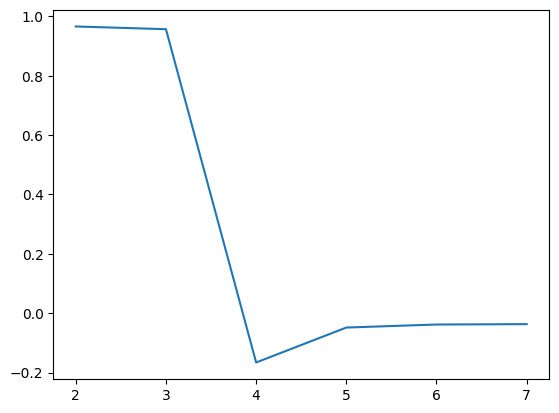

[[349.73726573]]


In [30]:
r2=[]
r2_max=0
for i in range(2,8):
    poly=PolynomialFeatures(degree=i)
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    model=LinearRegression()
    model.fit(x_train_poly,y_train)
    y_pred=model.predict(x_test_poly)
    r2.append(r2_score(y_pred,y_test))
    if r2_max<r2_score(y_pred,y_test):
        r2_max=r2_score(y_pred,y_test)
        y_ans=model.predict(poly.transform(np.array([[12,13,15,5,5]])))
plt.plot(range(2,8),r2)
plt.show()
print(y_ans)

In [31]:
x=np.array([5, 15, 25, 35, 45, 55]).reshape(6,1)
y=np.array([5, 20, 14, 32, 22, 38])
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
print(r2_score(y_pred,y))
print(model.coef_)
print(model.intercept_)
for i in np.arange(5):
    print(model.predict(np.array([[i]])))

0.603109282121628
[0.54]
5.633333333333329
[5.63333333]
[6.17333333]
[6.71333333]
[7.25333333]
[7.79333333]


In [32]:
df=pd.read_csv('real_estate.csv')
x=df[['size','year']]
y=df['price']
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
print(r2_score(y_pred,y))
print(model.coef_)
print(model.intercept_)
print(model.predict(np.array([[750,2009]])))


0.7121374334888604
[ 227.70085401 2916.78532684]
-5772267.017463277
[258330.34465995]


C:\Users\mistr\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
df=pd.read_csv('Position_Salaries.csv')
x=df[['Level']]
y=df[['Salary']]
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
model=LinearRegression()
model.fit(x_poly,y)
y_pred=model.predict(x_poly)
print(r2_score(y_pred,y))
print(model.coef_)
print(model.intercept_)
print(model.predict(poly.transform(np.array([[6.5]]))))

0.9808499387901425
[[     0.         180664.33566432 -48548.95104895   4120.04662005]]
[-121333.3333333]
[[133259.46969697]]


C:\Users\mistr\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [34]:
df=pd.read_csv("RealEstate.csv")
df=df.drop("No",axis=1)
x=df.drop('Y house price of unit area',axis=1)
y=df[["Y house price of unit area"]]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=110)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(model.coef_)
print(model.intercept_)
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


[[ 6.84308941e+00 -2.25466590e-01 -5.18046265e-03  1.12369103e+00
   1.87739728e+02 -4.29300312e+01]]
[-13203.67430063]
77.14802598253651
0.5447865064578795
